<a href="https://colab.research.google.com/github/enevarez-uees/UEES-MIA-Aprendizaje-Automatico/blob/main/semana-3/notebooks/S3_segmentacion_estudiantes_no_supervisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Segmentación de perfiles estudiantiles mediante técnicas de aprendizaje no supervisado

## Maestría en Inteligencia Artificial - UEES
## Materia de Aprendizaje Automático

### Integrantes
- Miguel Angel Behr Lopez
- Miguel Angel Chang
- Jhon Henry Quimi Loza
- Erik Ricardo Nevarez Benavidez

---

## Objetivo

Implementar y analizar modelos de aprendizaje no supervisado utilizando técnicas como K-Means, DBSCAN, PCA y t-SNE para segmentar perfiles estudiantiles en función de variables académicas y de comportamiento.

---

## Dataset utilizado

Se utilizó el dataset `student_performance.csv`, el cual contiene información relacionada con:
- horas de estudio,
- asistencia,
- desempeño previo,
- calificaciones finales,
- acceso a internet,
- actividades extracurriculares,
- entre otras variables relevantes para el análisis.

---

## Técnicas aplicadas

- Análisis exploratorio de datos (EDA)
- Limpieza y transformación de variables
- K-Means Clustering
- DBSCAN
- PCA
- t-SNE
- Visualización y análisis comparativo de clusters

# 1. Importación de librerías y carga del dataset

En esta sección se importan las librerías necesarias para el análisis exploratorio, procesamiento de datos, clustering y visualización de resultados.

In [1]:
# Librerías para manipulación de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para preprocesamiento
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Modelos de clustering
from sklearn.cluster import KMeans, DBSCAN

# Métricas de evaluación
from sklearn.metrics import silhouette_score

# Reducción de dimensionalidad
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# 2. Carga del dataset

Se carga el dataset relacionado con desempeño estudiantil para realizar el análisis de segmentación mediante técnicas de aprendizaje no supervisado.

In [2]:
# Cargar dataset
df = pd.read_csv('https://raw.githubusercontent.com/enevarez-uees/UEES-MIA-Aprendizaje-Automatico/refs/heads/main/semana-3/data/student_performance.csv')

# Mostrar primeras filas
df.head()

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes


# 3. Exploración inicial del dataset

En esta sección se realiza una exploración inicial del dataset para comprender su estructura, tipos de datos, dimensiones y posibles valores nulos.

In [3]:
# Dimensiones del dataset
print("Dimensiones del dataset:", df.shape)

# Información general
df.info()

Dimensiones del dataset: (500, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            500 non-null    object 
 1   gender                500 non-null    object 
 2   age                   500 non-null    int64  
 3   study_hours_per_week  500 non-null    int64  
 4   attendance_rate       500 non-null    float64
 5   parent_education      383 non-null    object 
 6   internet_access       500 non-null    object 
 7   extracurricular       500 non-null    object 
 8   previous_score        500 non-null    int64  
 9   final_score           500 non-null    int64  
 10  passed                500 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 43.1+ KB


In [4]:
# Estadísticas descriptivas
df.describe()

,age,study_hours_per_week,attendance_rate,previous_score,final_score
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,16.978000,15.312000,76.380600,62.986000,55.980000
std,1.434445,8.568167,13.817681,18.937451,15.373754
min,15.000000,2.000000,50.200000,30.000000,20.000000
25%,16.000000,8.000000,64.475000,46.000000,45.000000
50%,17.000000,15.000000,76.500000,64.000000,56.000000
75%,18.000000,23.000000,88.525000,79.000000,68.000000
max,19.000000,30.000000,100.000000,95.000000,95.000000


In [5]:
# Verificar valores nulos
df.isnull().sum()

,0
student_id,0
gender,0
age,0
study_hours_per_week,0
attendance_rate,0
parent_education,117
internet_access,0
extracurricular,0
previous_score,0
final_score,0


# 4. Limpieza y transformación de datos

En esta sección se realiza la limpieza del dataset y la transformación de variables categóricas para preparar los datos antes de aplicar los modelos de clustering.

Se identificó que la variable `parent_education` contiene valores nulos, por lo que será tratada antes del entrenamiento de los modelos.

In [6]:
# Verificar valores únicos de parent_education
df['parent_education'].value_counts(dropna=False)

,count
parent_education,
NaN,117
Master,100
Bachelor,97
High School,95
PhD,91


## Tratamiento de valores nulos

Debido a que la variable `parent_education` contiene una cantidad considerable de valores faltantes, se decidió reemplazarlos por la categoría `"Unknown"` en lugar de eliminar registros, evitando así la pérdida de información relevante para el análisis.

In [7]:
# Reemplazar valores nulos
df['parent_education'] = df['parent_education'].fillna('Desconocido')

# Verificar nuevamente valores nulos
df.isnull().sum()

,0
student_id,0
gender,0
age,0
study_hours_per_week,0
attendance_rate,0
parent_education,0
internet_access,0
extracurricular,0
previous_score,0
final_score,0


## Eliminación de variables irrelevantes

La variable `student_id` fue eliminada debido a que corresponde únicamente a un identificador único y no aporta información relevante para el proceso de segmentación.

In [8]:
# Eliminar columna irrelevante
df = df.drop(columns=['student_id'])

# Verificar columnas restantes
df.columns

Index(['gender', 'age', 'study_hours_per_week', 'attendance_rate',
       'parent_education', 'internet_access', 'extracurricular',
       'previous_score', 'final_score', 'passed'],
      dtype='object')

## Transformación de variables categóricas

Las variables categóricas fueron transformadas a valores numéricos mediante `LabelEncoder`, debido a que los algoritmos de clustering requieren datos numéricos para calcular distancias y agrupamientos.

In [9]:
# Crear copia del dataset
df_cluster = df.copy()

# Inicializar LabelEncoder
le = LabelEncoder()

# Variables categóricas
categorical_columns = [
    'gender',
    'parent_education',
    'internet_access',
    'extracurricular',
    'passed'
]

# Transformar variables categóricas
for col in categorical_columns:
    df_cluster[col] = le.fit_transform(df_cluster[col])

# Mostrar primeras filas transformadas
df_cluster.head()

,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,1,15,25,63.8,0,1,1,41,67,1
1,0,15,2,54.7,0,1,1,83,28,0
2,0,19,10,90.5,2,1,0,73,49,0
3,1,16,26,66.8,2,0,1,75,70,1
4,0,15,25,73.0,2,0,1,67,77,1


## Normalización de variables

Las variables fueron normalizadas utilizando `StandardScaler` para evitar que diferencias de escala afecten el cálculo de distancias en los modelos de clustering.

In [10]:
# Inicializar scaler
scaler = StandardScaler()

# Escalar datos
scaled_data = scaler.fit_transform(df_cluster)

# Convertir a DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=df_cluster.columns)

# Mostrar primeras filas escaladas
scaled_df.head()

,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,1.096651,-1.380312,1.131829,-0.911383,-1.396206,0.984126,1.012073,-1.162143,0.717524,0.740262
1,-0.911867,-1.380312,-1.555214,-1.570619,-1.396206,0.984126,1.012073,1.057906,-1.821808,-1.350873
2,-0.911867,1.411017,-0.620590,1.022859,0.041699,0.984126,-0.988071,0.529323,-0.454475,-1.350873
3,1.096651,-0.682480,1.248657,-0.694052,0.041699,-1.016130,1.012073,0.635040,0.912857,0.740262
4,-0.911867,-1.380312,1.131829,-0.244903,0.041699,-1.016130,1.012073,0.212173,1.368635,0.740262


# 5. Análisis exploratorio visual

Se realizan visualizaciones para identificar relaciones entre variables, distribuciones y posibles patrones relevantes antes de aplicar los modelos de segmentación.

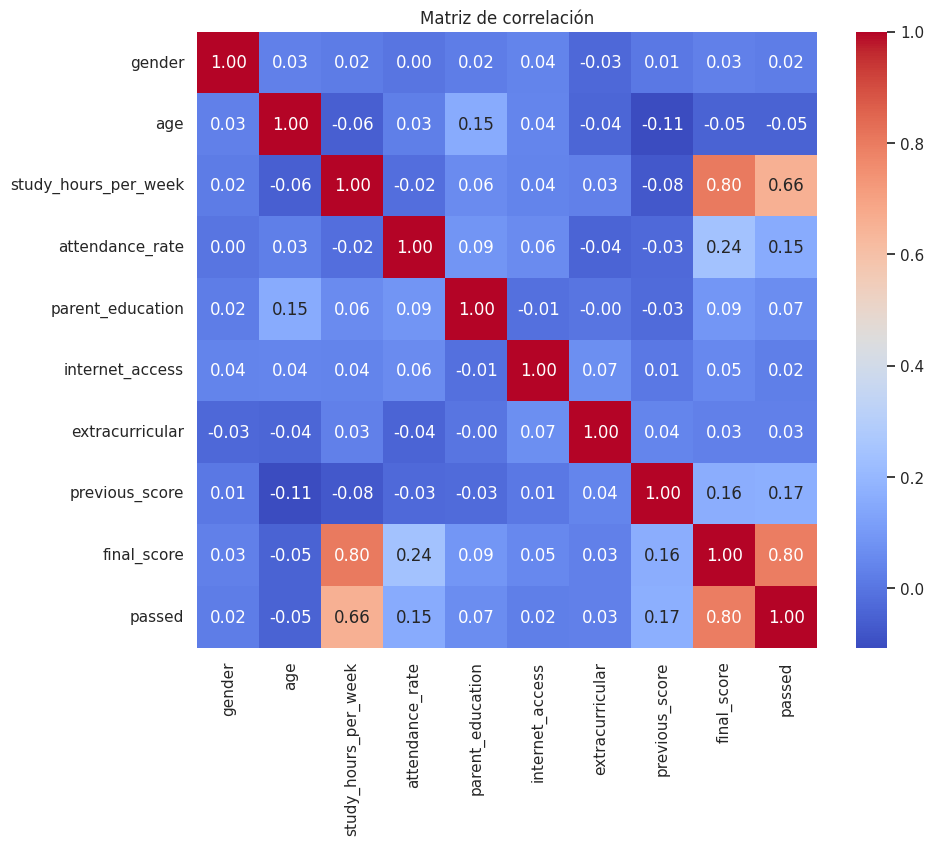

In [11]:
# Matriz de correlación
plt.figure(figsize=(10,8))

sns.heatmap(
    df_cluster.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de correlación')
plt.show()

### Interpretación de correlaciones

A partir de la matriz de correlación se identificó que las variables con mayor relación respecto al desempeño académico fueron:

- `study_hours_per_week` y `final_score`, mostrando una correlación positiva alta.
- `final_score` y `passed`, lo cual resulta coherente debido a que las calificaciones finales influyen directamente en la aprobación.
- `attendance_rate` presentó una correlación moderada con el desempeño final.

En general, las horas de estudio parecen tener mayor impacto sobre el rendimiento académico que otras variables del dataset.

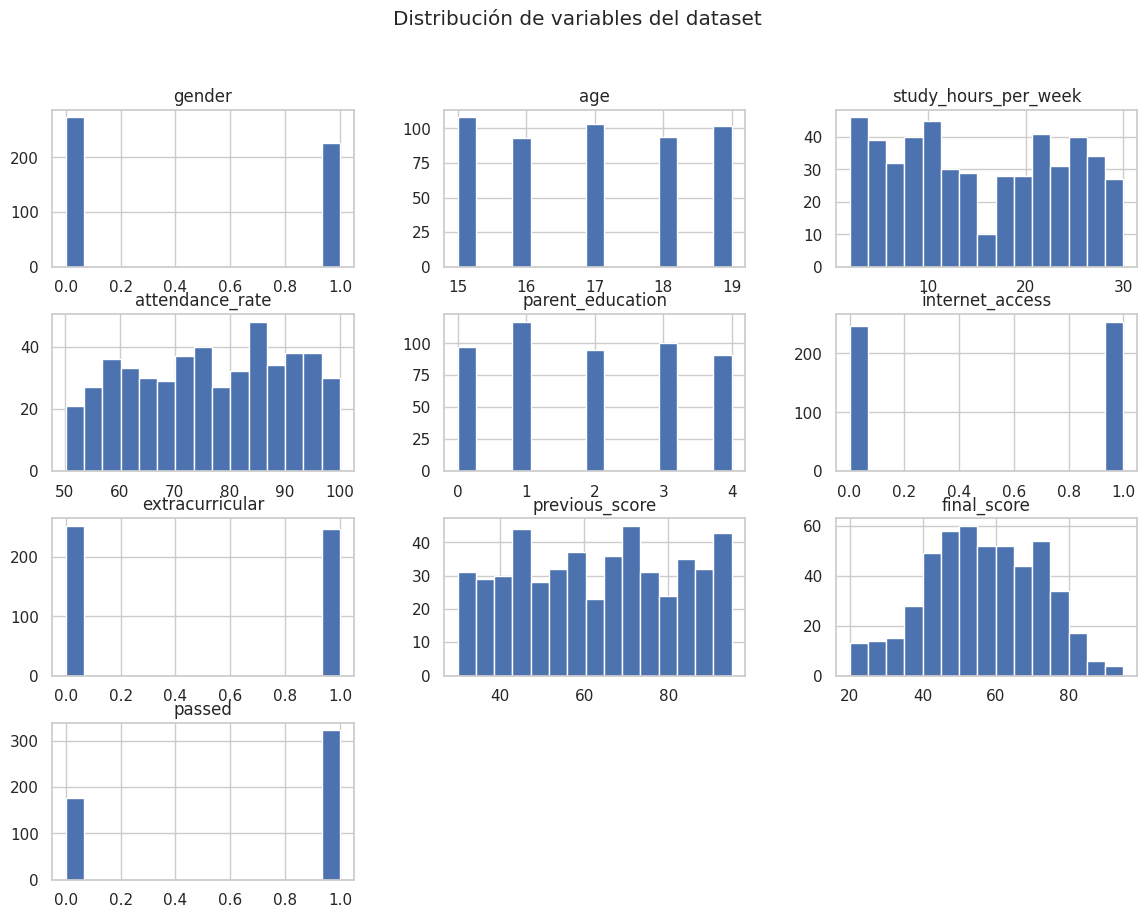

In [13]:
# Histogramas de variables numéricas
df_cluster.hist(figsize=(14,10), bins=15)

plt.suptitle('Distribución de variables del dataset')
plt.show()

# 6. Implementación de K-Means

Para determinar el número óptimo de clusters se aplicó el método del codo (Elbow Method), evaluando la inercia generada por diferentes cantidades de agrupamientos.

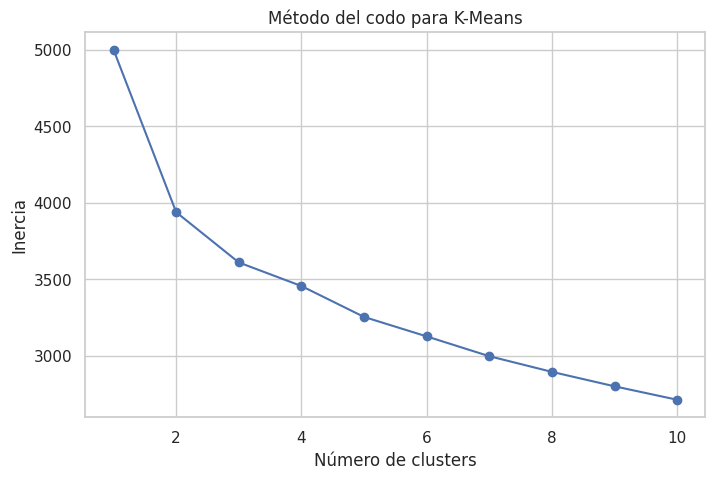

In [14]:
# Método del codo
inertia = []

k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

# Graficar método del codo
plt.figure(figsize=(8,5))

plt.plot(k_values, inertia, marker='o')

plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del codo para K-Means')

plt.show()

## Evaluación mediante Silhouette Score

Además del método del codo, se utilizó la métrica Silhouette Score para evaluar la calidad de separación entre clusters y validar el número óptimo de agrupamientos.

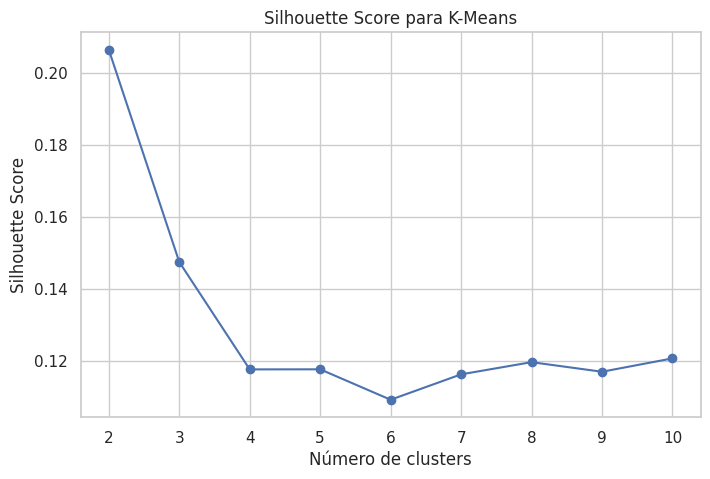

Clusters: 2 - Score: 0.2065
Clusters: 3 - Score: 0.1475
Clusters: 4 - Score: 0.1177
Clusters: 5 - Score: 0.1177
Clusters: 6 - Score: 0.1092
Clusters: 7 - Score: 0.1163
Clusters: 8 - Score: 0.1197
Clusters: 9 - Score: 0.1170
Clusters: 10 - Score: 0.1207


In [15]:
# Evaluar silhouette score
silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(scaled_df)

    score = silhouette_score(scaled_df, labels)

    silhouette_scores.append(score)

# Graficar silhouette scores
plt.figure(figsize=(8,5))

plt.plot(range(2,11), silhouette_scores, marker='o')

plt.xlabel('Número de clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score para K-Means')

plt.show()

# Mostrar resultados
for k, score in zip(range(2,11), silhouette_scores):
    print(f'Clusters: {k} - Score: {score:.4f}')

## Selección final de clusters

Aunque el valor más alto de Silhouette Score se obtuvo con 2 clusters, se decidió utilizar 3 clusters debido a que el método del codo mostró una segmentación más interpretable y adecuada para el análisis de perfiles estudiantiles.

In [16]:
# Modelo final K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Entrenar modelo
df_cluster['kmeans_cluster'] = kmeans.fit_predict(scaled_df)

# Ver cantidad de registros por cluster
df_cluster['kmeans_cluster'].value_counts()

,count
kmeans_cluster,
0,177
1,163
2,160


# 7. Reducción de dimensionalidad con PCA

Se aplicó PCA (Principal Component Analysis) para reducir la dimensionalidad del dataset y visualizar gráficamente la distribución de los clusters generados por K-Means.

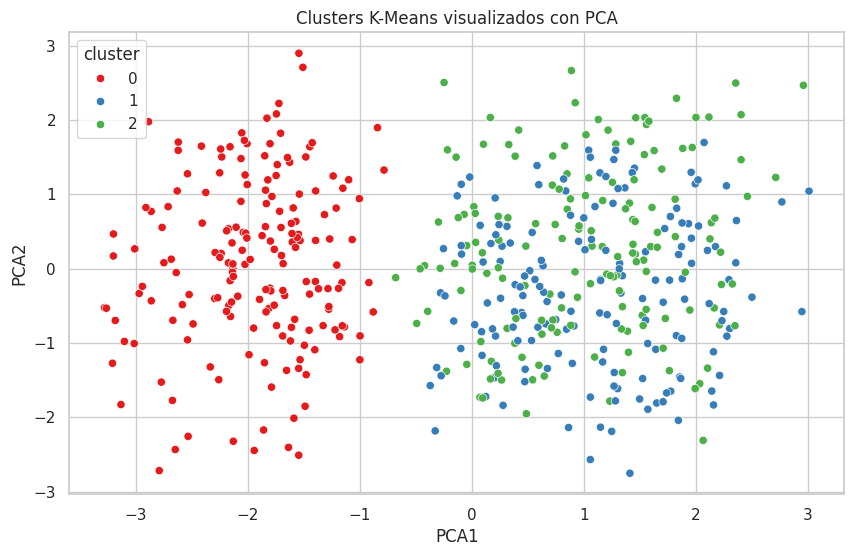

In [17]:
# Aplicar PCA
pca = PCA(n_components=2)

pca_components = pca.fit_transform(scaled_df)

# Crear DataFrame PCA
pca_df = pd.DataFrame(
    data=pca_components,
    columns=['PCA1', 'PCA2']
)

# Agregar clusters
pca_df['cluster'] = df_cluster['kmeans_cluster']

# Visualizar clusters
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x='PCA1',
    y='PCA2',
    hue='cluster',
    palette='Set1'
)

plt.title('Clusters K-Means visualizados con PCA')

plt.show()

# 8. Implementación de DBSCAN

Se aplicó el algoritmo DBSCAN para identificar agrupamientos basados en densidad y detectar posibles observaciones atípicas dentro del dataset.

In [19]:
# Modelo DBSCAN ajustado
dbscan = DBSCAN(
    eps=2.2,
    min_samples=8
)

# Entrenar modelo
dbscan_labels = dbscan.fit_predict(scaled_df)

# Agregar clusters al dataset
df_cluster['dbscan_cluster'] = dbscan_labels

# Ver cantidad de registros por cluster
df_cluster['dbscan_cluster'].value_counts()

,count
dbscan_cluster,
0,300
-1,90
1,86
2,12
3,12


### Visualización de clusters DBSCAN

Para visualizar los resultados obtenidos con DBSCAN, se utilizó PCA para reducir la dimensionalidad del dataset y representar gráficamente los agrupamientos detectados.

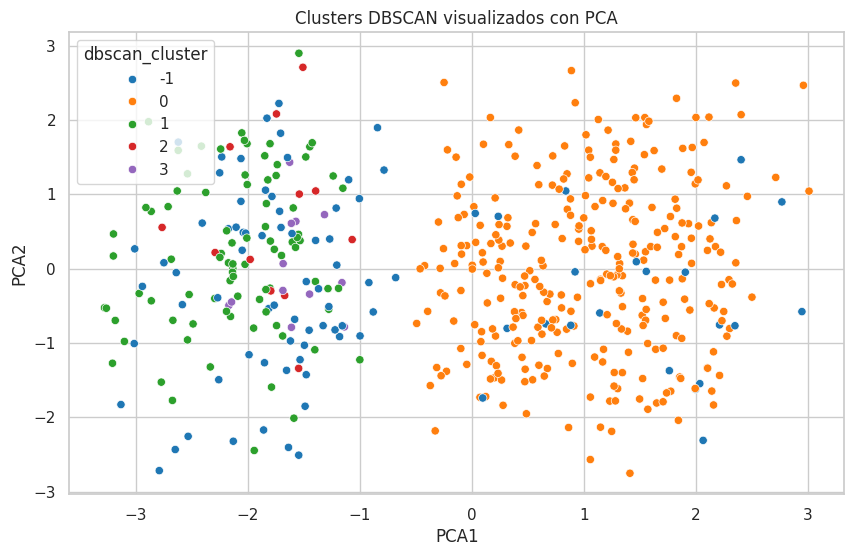

In [20]:
# Crear DataFrame PCA para DBSCAN
pca_dbscan = pca_df.copy()

# Agregar labels DBSCAN
pca_dbscan['dbscan_cluster'] = df_cluster['dbscan_cluster']

# Visualizar clusters DBSCAN
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_dbscan,
    x='PCA1',
    y='PCA2',
    hue='dbscan_cluster',
    palette='tab10'
)

plt.title('Clusters DBSCAN visualizados con PCA')

plt.show()

## 9. Visualización mediante t-SNE

Se aplicó la técnica t-SNE (t-distributed Stochastic Neighbor Embedding) para visualizar en dos dimensiones la distribución de los datos y observar la separación entre clusters de forma no lineal.

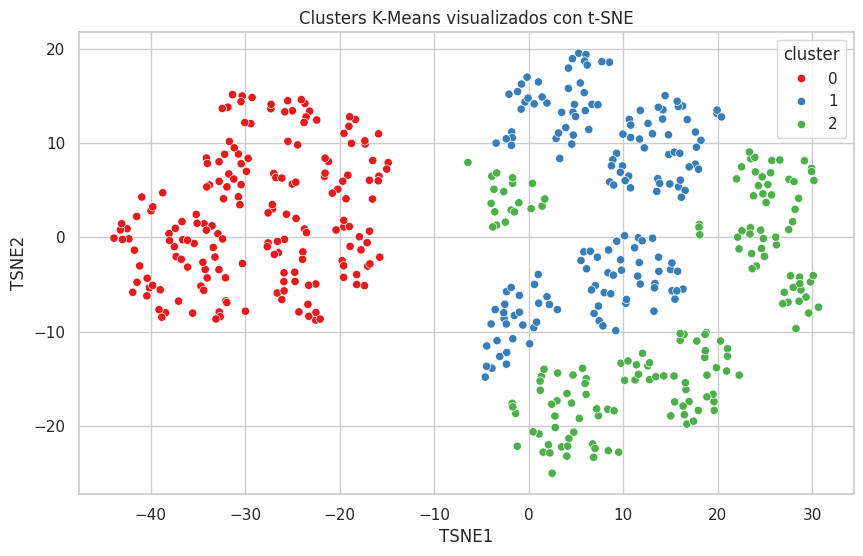

In [21]:
# Aplicar t-SNE
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

tsne_components = tsne.fit_transform(scaled_df)

# Crear DataFrame t-SNE
tsne_df = pd.DataFrame(
    tsne_components,
    columns=['TSNE1', 'TSNE2']
)

# Agregar clusters K-Means
tsne_df['cluster'] = df_cluster['kmeans_cluster']

# Visualizar t-SNE
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=tsne_df,
    x='TSNE1',
    y='TSNE2',
    hue='cluster',
    palette='Set1'
)

plt.title('Clusters K-Means visualizados con t-SNE')

plt.show()